### 1 - Importation des librairies

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
import os
import pandas as pd
plt.rcParams['figure.figsize']=[12, 10]  # Affiche la taille par défaut des graphiques [largeur, hauteur]
plt.rcParams['font.size'] = 12    # Affiche la taille de la police par défaut
pd.set_option('display.width', 140)

### Chargement des données depuis ***Data_Processed***

In [3]:
malaria = pd.read_csv("../Data_Processed/malariaIncidenceAfrique2000_2022.csv")
mortality = pd.read_csv("../Data_Processed/Mortality_Maternal.csv")
prenatal = pd.read_csv("../Data_Processed/Soins_Prenatal.csv")

who_data = pd.read_csv("../Data_Supplementaire/world_health_data.csv")

### 2- Analyse Exploratoire des données (EDA)

In [4]:
target_country = ['Benin','Burkina Faso',"Cote d'Ivoire",'Ghana','Mali','Niger','Nigeria','Senegal','Togo']

#### A -  Malaria

In [7]:
print(f"\n ============ INCIDENCE MALARIA==============\n")

print(f"Dimensions : {malaria.shape}\n")
print(f"Doublons (Entity+ Year)\n: {malaria.duplicated(subset=['Entity', "Year"]).sum()}\n")
print(f"Nombre total de doublons\n: {malaria.duplicated().sum()}\n")

print(f"Valeurs Manuantes\n: {malaria.isna().sum()}")

print(f"Codes ISO par pays\n: {malaria.groupby("Entity")["Code"].unique()}")

# coouverture anné par pays
print(f"Couverture année par pays: \n")
cover = malaria.groupby("Entity")['Year'].agg(['min', 'max', 'count'])
print(cover)

print(f"Statistiques de l'indicateur\n: {malaria["Incidence of malaria (per 1,000 population at risk)"].describe()}")


 ============ INCIDENCE MALARIA==============

Dimensions : (207, 4)

Doublons (Entity+ Year)
: 0

Nombre total de doublons
: 0

Valeurs Manuantes
: Entity                                                 0
Code                                                   0
Year                                                   0
Incidence of malaria (per 1,000 population at risk)    0
dtype: int64
Codes ISO par pays
: Entity
Benin            [BEN]
Burkina Faso     [BFA]
Cote d'Ivoire    [CIV]
Ghana            [GHA]
Mali             [MLI]
Niger            [NER]
Nigeria          [NGA]
Senegal          [SEN]
Togo             [TGO]
Name: Code, dtype: object
Couverture année par pays: 

                min   max  count
Entity                          
Benin          2000  2022     23
Burkina Faso   2000  2022     23
Cote d'Ivoire  2000  2022     23
Ghana          2000  2022     23
Mali           2000  2022     23
Niger          2000  2022     23
Nigeria        2000  2022     23
Senegal        2000  2

#### B - Mortality Maternal

In [8]:
print("===========\nMORTALITE MATERNELLE====================\n",)
print("Doublons (Entity+Year):", mortality.duplicated(subset=['Entity','Year']).sum())
print("Valeurs manquantes:\n", mortality.isna().sum())
print("\nCouverture années par pays:")
cov = mortality.groupby('Entity')['Year'].agg(['min','max','count'])
print(cov)
print("\nStats indicateur:\n", mortality['Maternal mortality ratio'].describe())

# chercher des trous internes (pas juste min/max mais séquence complète)
print("\nAnnées manquantes en interne (hors 2000-2022):")
full_years = set(range(2000,2022))
for e,g in mortality.groupby('Entity'):
    missing = full_years - set(g['Year'])
    if missing:
        print(e, sorted(missing))

MORTALITE MATERNELLE====================

Doublons (Entity+Year): 0
Valeurs manquantes:
 Entity                      0
Code                        0
Year                        0
Maternal mortality ratio    0
dtype: int64

Couverture années par pays:
                min   max  count
Entity                          
Benin          2000  2022     23
Burkina Faso   2000  2022     23
Cote d'Ivoire  2000  2022     23
Ghana          2000  2022     23
Mali           2000  2022     23
Niger          2000  2022     23
Nigeria        2000  2022     23
Senegal        2000  2022     23
Togo           2000  2022     23

Stats indicateur:
 count     207.000000
mean      544.439202
std       228.524831
min       228.242390
25%       404.696595
50%       488.122280
75%       584.250480
max      1167.736700
Name: Maternal mortality ratio, dtype: float64

Années manquantes en interne (hors 2000-2022):


In [10]:
print("Valeur max (contexte):")
print(mortality.loc[mortality['Maternal mortality ratio'].idxmax()])
print("\nValeur min (contexte):")
print(mortality.loc[mortality['Maternal mortality ratio'].idxmin()])

# detection des valeurs aberrantes(outliers) par la methode d'interquatile
Q1 = mortality['Maternal mortality ratio'].quantile(0.25)
Q3 = mortality['Maternal mortality ratio'].quantile(0.75)
IQR = Q3-Q1
low, high = Q1-1.5*IQR, Q3+1.5*IQR
out = mortality[(mortality['Maternal mortality ratio']<low)|(mortality['Maternal mortality ratio']>high)]
print(f"\nBornes IQR: [{low:.1f}, {high:.1f}]  -> {len(out)} outliers globaux")
print(out[['Entity','Year','Maternal mortality ratio']] if len(out) else "Aucun")

print("\n=========SOINS PRENATAUX===============\n")

print("Doublons (Entity+Year):", prenatal.duplicated(subset=['Entity','Year']).sum())
print("Valeurs manquantes:\n", prenatal.isna().sum())
cov = prenatal.groupby('Entity')['Year'].agg(['min','max','count'])
print("\nCouverture par pays:\n", cov)
print("\nStats:\n", prenatal['Pregnant women receiving prenatal care (%)'].describe())
# valeurs hors [0,100] ?
col = 'Pregnant women receiving prenatal care (%)'
bad = prenatal[(prenatal[col]<0)|(prenatal[col]>100)]
print(f"\nValeurs hors intervalle [0,100]%: {len(bad)}")
print(bad if len(bad) else "Aucune")

Valeur max (contexte):
Entity                        Nigeria
Code                              NGA
Year                             2015
Maternal mortality ratio    1167.7367
Name: 153, dtype: object

Valeur min (contexte):
Entity                        Senegal
Code                              SEN
Year                             2022
Maternal mortality ratio    228.24239
Name: 183, dtype: object

Bornes IQR: [135.4, 853.6]  -> 23 outliers globaux
      Entity  Year  Maternal mortality ratio
138  Nigeria  2000                1135.67350
139  Nigeria  2001                1129.84690
140  Nigeria  2002                1116.64990
141  Nigeria  2003                1090.39150
142  Nigeria  2004                1075.12460
143  Nigeria  2005                1059.81030
144  Nigeria  2006                1067.33620
145  Nigeria  2007                1063.35470
146  Nigeria  2008                1081.42980
147  Nigeria  2009                1088.09790
148  Nigeria  2010                1093.74330
149  Ni

In [11]:
print("Valeur min (contexte):")
print(prenatal.loc[prenatal['Pregnant women receiving prenatal care (%)'].idxmin()])
print("\nDétail des années disponibles par pays (soins prénataux):")
for v,l in prenatal.groupby('Entity'):
    print(f"{e}: {sorted(g['Year'].tolist())}")

print("\n==============WORLD_HEALTH_DATA (supplémentaire)\n========================")
who_data = who_data[who_data['country'].isin(target_country)].copy()
print("Nb lignes pour nos 9 pays:", len(who_data))
print("Noms de pays trouvés (vérif orthographe identique):", sorted(who_data['country'].unique()))
missing_countries = set(target_country) - set(who_data['country'].unique())
print("Pays de notre liste absents de world_health_data:", missing_countries if missing_countries else "Aucun - tous présents")

print("\nCouverture années par pays (world_health, nos 9 pays):")
print(who_data.groupby('country')['year'].agg(['min','max','count']))

print("\nValeurs manquantes par colonne (nos 9 pays uniquement, années 2000-2022):")
who_scope = who_data[(who_data['year']>=2000)&(who_data['year']<=2022)]
print(who_scope.isna().sum())
print("\nTaux de complétude (%) par colonne:")
print((100 - who_scope.isna().mean()*100).round(1))

Valeur min (contexte):
Entity                                        Mali
Code                                           MLI
Year                                          2010
Pregnant women receiving prenatal care (%)    34.7
Name: 28, dtype: object

Détail des années disponibles par pays (soins prénataux):
Togo: [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]
Togo: [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]
Togo: [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]
Togo: [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]
Togo: [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2

#### Resulats des analyses

#### 1-EDA: Paludisme

0 doublon, 0 valeur manquante, 23/23 années pour les 9 pays
Codes ISO cohérents (BEN, BFA, CIV, GHA, MLI, NER, NGA, SEN, TGO)
Incidence : min 32,9 — max 597,5 — moyenne 349,2 (dispersion normale, rien d'aberrant)

#### 2 -EDA: Mortalité maternelle

0 doublon, 0 valeur manquante, 23/23 années confirmées pour les 9 pays (2021-2022 bien présents maintenant)
Un test IQR global détecte 23 "outliers" : ce sont en fait les 23 années du Nigeria en entier (900-1168, largement au-dessus des autres pays). Ce n'est pas une erreur de données : le Nigeria a structurellement un niveau de mortalité maternelle très supérieur au reste du groupe.

→ Point méthodologique à documenter : la détection d'outliers par IQR global ne fonctionne pas bien sur des données de panel (pays × années) .elle confond pays structurellement différent et valeur aberrante. 

Pour ce projet, mieux vaut détecter les anomalies par pays (ruptures/sauts brusques d'une année sur l'autre) plutôt que sur la distribution globale. 

#### 3 - EDA — Soins prénataux

0 doublon, 0 valeur manquante, toutes les valeurs dans [0,100]%
Couverture très inégale (4 points pour le Niger, 12 pour le Sénégal) — c'est structurel à la source, pas un problème de qualité
Valeur min : Mali 2010 à 34,7% — plausible dans le contexte, pas une anomalie

***world_health_data.csv***
Noms de pays strictement identiques à nos 3 fichiers (Cote d'Ivoire, etc.) → aucune harmonisation nécessaire pour la jointure, contrairement à ce qu'on craignait
Couverture 1999-2023 (25 années) pour les 9 pays, donc couvre bien large que notre fenêtre 2000-2022
Complétude par indicateur (sur nos 9 pays, 2000-2022) :


⚠️ Point d'attention : world_health_data.csv contient sa propre colonne maternal_mortality, probablement une autre source/méthodologie que notre fichier OWID principal. Il ne faut pas les fusionner en une seule série (ça biaiserait les tendances en mélangeant deux méthodologies) 

### C- VISUALITIONS GRAPHIQUES

#### 1- Tendance paludisme 2000-2022

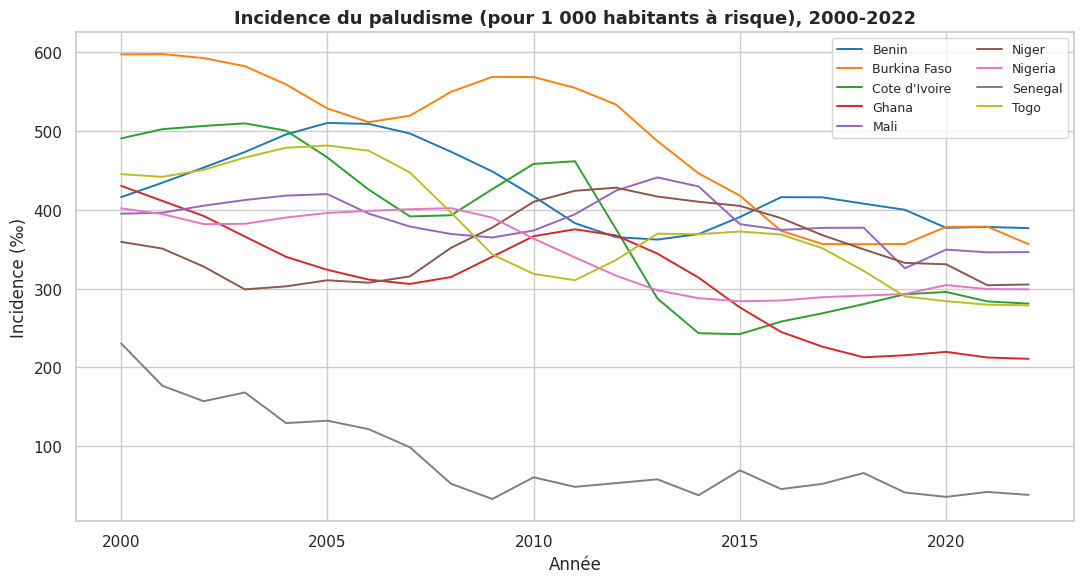

In [12]:
sns.set_theme(style="whitegrid", palette="tab10")

fig, ax = plt.subplots(figsize=(11,6))
for pays, g in malaria.groupby('Entity'):
    g = g.sort_values('Year')
    lw = 2.8 if pays == 'Sénégal' else 1.4
    ax.plot(g['Year'], g['Incidence of malaria (per 1,000 population at risk)'], label=pays, linewidth=lw)
ax.set_title("Incidence du paludisme (pour 1 000 habitants à risque), 2000-2022", fontsize=13, fontweight='bold')
ax.set_xlabel("Année"); ax.set_ylabel("Incidence (‰)")
ax.legend(loc='upper right', ncol=2, fontsize=9)
plt.tight_layout()
plt.show()
plt.close()

* Sénégal en chute nette et continue

#### 2- Tendance Mortalité Maternelle par Pays 200-2022

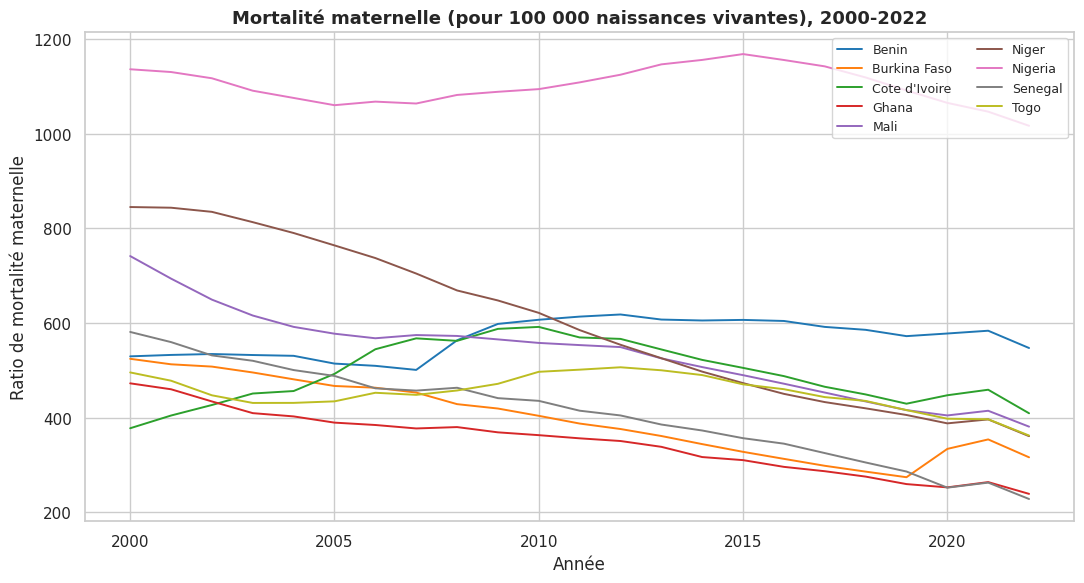

In [14]:
fig, ax = plt.subplots(figsize=(11,6))
for pays, g in mortality.groupby('Entity'):
    g = g.sort_values('Year')
    lw = 2.8 if pays == 'Sénégal' else 1.4
    ax.plot(g['Year'], g['Maternal mortality ratio'], label=pays, linewidth=lw)
ax.set_title("Mortalité maternelle (pour 100 000 naissances vivantes), 2000-2022", fontsize=13, fontweight='bold')
ax.set_xlabel("Année"); ax.set_ylabel("Ratio de mortalité maternelle")
ax.legend(loc='upper right', ncol=2, fontsize=9)
plt.tight_layout()
plt.show()
plt.close()


* Nigeria reste sur un plateau structurellement très supérieur au groupe

#### 3 - Variation % 2000 - 2022

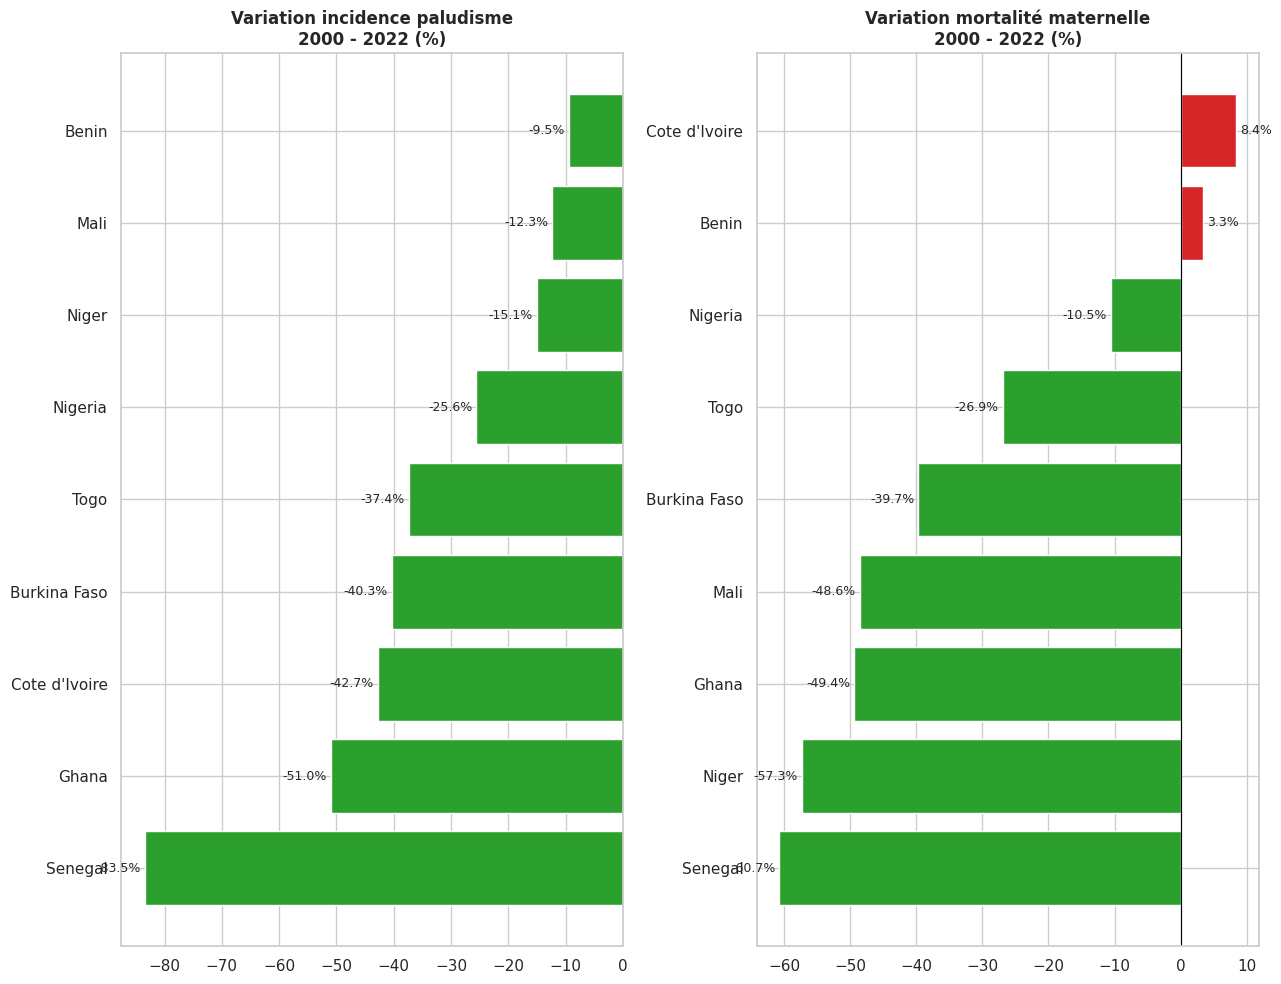

Variation paludisme (%):
 Entity
Senegal         -83.5
Ghana           -51.0
Cote d'Ivoire   -42.7
Burkina Faso    -40.3
Togo            -37.4
Nigeria         -25.6
Niger           -15.1
Mali            -12.3
Benin            -9.5
Name: Incidence of malaria (per 1,000 population at risk), dtype: float64

Variation mortalité maternelle (%):
 Entity
Senegal         -60.7
Niger           -57.3
Ghana           -49.4
Mali            -48.6
Burkina Faso    -39.7
Togo            -26.9
Nigeria         -10.5
Benin             3.3
Cote d'Ivoire     8.4
Name: Maternal mortality ratio, dtype: float64


In [18]:
def variation(df, col):
    d0 = df[df['Year']==2000].set_index('Entity')[col]
    d1 = df[df['Year']==2022].set_index('Entity')[col]
    return ((d1-d0)/d0*100).sort_values()

var_mal = variation(malaria, 'Incidence of malaria (per 1,000 population at risk)')
var_mat = variation(mortality, 'Maternal mortality ratio')

fig, axes = plt.subplots(1, 2, figsize=(13,10))
colors1 = ['#2ca02c' if v<0 else '#d62728' for v in var_mal.values]
axes[0].barh(var_mal.index, var_mal.values, color=colors1)
axes[0].set_title("Variation incidence paludisme\n2000 - 2022 (%)", fontweight='bold')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].bar_label(axes[0].containers[0], fmt='%.1f%%', padding=3, fontsize=9)

colors2 = ['#2ca02c' if v<0 else '#d62728' for v in var_mat.values]
axes[1].barh(var_mat.index, var_mat.values, color=colors2)
axes[1].set_title("Variation mortalité maternelle\n2000 - 2022 (%)", fontweight='bold')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].bar_label(axes[1].containers[0], fmt='%.1f%%', padding=3, fontsize=9)

plt.tight_layout()
plt.show()
plt.close()

print("Variation paludisme (%):\n", var_mal.round(1))
print("\nVariation mortalité maternelle (%):\n", var_mat.round(1))

* Paludisme : Sénégal −83,5% (loin devant), Bénin quasi stagnant (−9,5%)
* Mortalité maternelle : Sénégal −60,7%, Niger −57,3% en tête ; Côte d'Ivoire (+8,4%) et Bénin (+3,3%) en hausse .ce sont les 2 points les plus critiques à creuser

#### 4 - Couvertures des Soins Prenataux

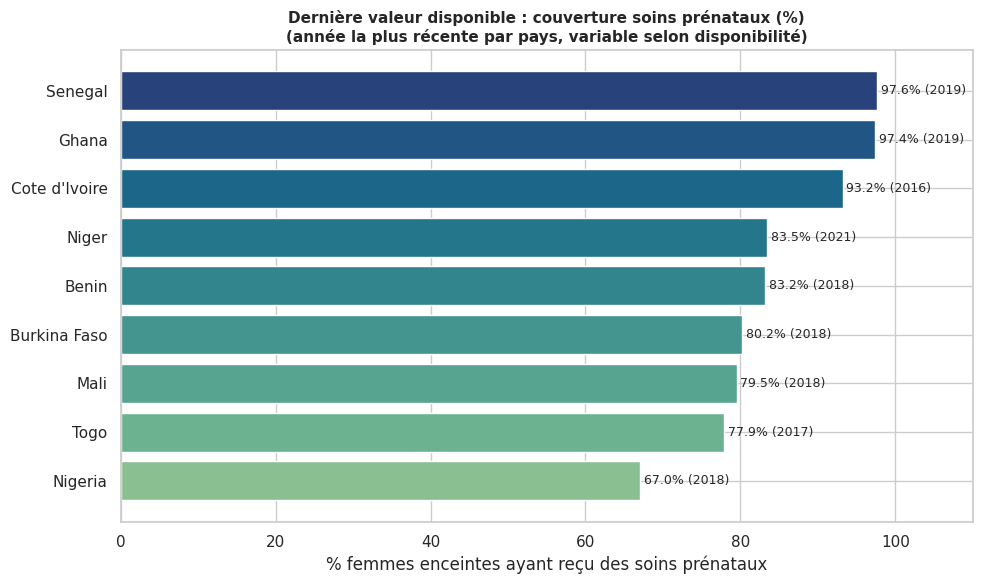

               Year  Pregnant women receiving prenatal care (%)
Entity                                                         
Nigeria        2018                                        67.0
Togo           2017                                        77.9
Mali           2018                                        79.5
Burkina Faso   2018                                        80.2
Benin          2018                                        83.2
Niger          2021                                        83.5
Cote d'Ivoire  2016                                        93.2
Ghana          2019                                        97.4
Senegal        2019                                        97.6


In [19]:
last_val = prenatal.sort_values('Year').groupby('Entity').last()[['Year','Pregnant women receiving prenatal care (%)']]
last_val = last_val.sort_values('Pregnant women receiving prenatal care (%)')

fig, ax = plt.subplots(figsize=(10,6))
bars = ax.barh(last_val.index, last_val['Pregnant women receiving prenatal care (%)'], color=sns.color_palette("crest", len(last_val)))
ax.set_title("Dernière valeur disponible : couverture soins prénataux (%)\n(année la plus récente par pays, variable selon disponibilité)", fontweight='bold', fontsize=11)
ax.set_xlabel("% femmes enceintes ayant reçu des soins prénataux")
for i,(idx,row) in enumerate(last_val.iterrows()):
    ax.text(row['Pregnant women receiving prenatal care (%)']+0.5, i, f"{row['Pregnant women receiving prenatal care (%)']:.1f}% ({int(row['Year'])})", va='center', fontsize=9)
ax.set_xlim(0,110)
plt.tight_layout()
plt.show()
plt.close()
print(last_val)

 Sénégal et Ghana au-dessus de 97%, Nigeria le plus faible à 67% (2018)

#### Dernière ligne droite avant le tableau de board

In [20]:
frames = []

#  Paludisme
malaria = malaria.rename(columns={'Incidence of malaria (per 1,000 population at risk)':'Value_Malaria'})
malaria['Indicateur'] = 'Incidence du paludisme'
malaria['Unite'] = 'pour 1 000 habitants à risque'
malaria['Source'] = 'Our World in Data (OWID)'
frames.append(malaria[['Entity','Code','Year','Indicateur','Value_Malaria','Unite','Source']])

# Mortalité maternelle (source principale OWID) 
mortality = mortality.rename(columns={'Maternal mortality ratio':'%Mortality'})
mortality['Indicateur'] = 'Mortalité maternelle'
mortality['Unite'] = 'pour 100 000 naissances vivantes'
mortality['Source'] = 'Our World in Data (OWID)'
frames.append(mortality[['Entity','Code','Year','Indicateur','%Mortality','Unite','Source']])

# Soins prénataux
prenatal = prenatal.rename(columns={'Pregnant women receiving prenatal care (%)':'soins_prenatal'})
prenatal['Indicateur'] = 'Couverture soins prénataux'
prenatal['Unite'] = '%'
prenatal['Source'] = 'Our World in Data (OWID)'
frames.append(prenatal[['Entity','Code','Year','Indicateur','soins_prenatal','Unite','Source']])

# World Health Data 
who_data = who_data[(who_data['country'].isin(target_country)) & (who_data['year']>=2000) & (who_data['year']<=2022)].copy()
who_data = who_data.rename(columns={'country':'Entity','country_code':'Code','year':'Year'})

mapping = {
    'health_exp': ('Dépenses de santé', '% du PIB'),
    'life_expect': ('Espérance de vie', 'années'),
    'infant_mortality': ('Mortalité infantile', 'pour 1 000 naissances vivantes'),
    'neonatal_mortality': ('Mortalité néonatale', 'pour 1 000 naissances vivantes'),
    'under_5_mortality': ('Mortalité des moins de 5 ans', 'pour 1 000 naissances vivantes'),
}

for col, (nom_indicateur, unite) in mapping.items():
    tmp = who_data[['Entity','Code','Year',col]].rename(columns={col:'Valeur'}).dropna(subset=['Valeur'])
    tmp['Indicateur'] = nom_indicateur
    tmp['Unite'] = unite
    tmp['Source'] = 'World Health Data (Kaggle, enrichissement)'
    frames.append(tmp[['Entity','Code','Year','Indicateur','Valeur','Unite','Source']])

data_final = pd.concat(frames, ignore_index=True)
data_final = data_final[['Entity','Code','Year','Indicateur','Valeur','Unite','Source']]
data_final = data_final.sort_values(['Entity','Indicateur','Year']).reset_index(drop=True)


In [21]:
import pathlib

# récupère le dossier où se trouve le notebook
notebook_dir = pathlib.Path.cwd()

# racine projet
root_dir = notebook_dir.parent.parent

# creer un dssier de stockage à la racine 

final_dir = root_dir / "Data_Final"

# On crée le dossier s'il n'existe pas (parents=True évite les erreurs, exist_ok=True ne fait rien s'il existe déjà)
final_dir.mkdir(parents=True, exist_ok=True)

data_final.to_csv(final_dir / "data.csv", index=False)
